# Extração dos textos - ESJs

O objetivo deste código é extrair o texto do PDF de todos os processos disponíveis. Como resultado, teremos uma base de dados com duas colunas: ID do processo e texto, que sera uma entrada string que contém todo o texto dos processos.

## Importando pacotes e definindo diretório

In [12]:
!pip install pdfplumber

In [13]:
import os
import pandas as pd
import re
import random
import shutil
import pdfplumber
import numpy as np
import time
from pdf2image import convert_from_path
from PIL import Image
import pytesseract
from fpdf import FPDF
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

Agora, vamos definir o caminho da pasta que tem os arquivos:

In [14]:
pasta_principal = "D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs"

## Extração dos textos e criação do df

In [15]:
def extrair_texto_pdf(caminho_pdf):
    # Definimos o caminho para o pdf
    nome_arquivo = os.path.basename(caminho_pdf)

    # Padrões para extrair os arquivos, análogos aos dos outros códigos.
    pattern_processo_nome_arquivo = r"(?:\d{5}-\d{6}-\d{4}-\d{2}|IA-\d{4}-\d{2}|RJ-\d{4}-\d{5}|SP-\d{4}-\d{5})"
    match_processo_nome_arquivo = re.search(pattern_processo_nome_arquivo, nome_arquivo)
    numero_processo = match_processo_nome_arquivo.group(0) if match_processo_nome_arquivo else np.nan

    # Extração do texto:
    with pdfplumber.open(caminho_pdf) as pdf: #Abrir o PDF
        text = "\n".join(page.extract_text() or "" for page in pdf.pages) #Extrair o texto

    return numero_processo, text #Retornamos o número do processo e o texto.

Adicionando os escaneados:

In [16]:
def extrair_texto_pdf(caminho_pdf, min_chars=10000):
    """
    Extrai texto de um PDF. Se o texto for vazio ou muito curto, tenta OCR.
    Retorna (numero_processo, texto, escaneado)
    """
    # 1️⃣ Número do processo a partir do nome do arquivo
    nome_arquivo = os.path.basename(caminho_pdf)
    pattern_processo_nome_arquivo = r"(?:\d{5}-\d{6}-\d{4}-\d{2}|IA-\d{4}-\d{2}|RJ-\d{4}-\d{5}|SP-\d{4}-\d{5})"
    match_processo_nome_arquivo = re.search(pattern_processo_nome_arquivo, nome_arquivo)
    numero_processo = match_processo_nome_arquivo.group(0) if match_processo_nome_arquivo else np.nan
    
    # Inicializar a variável escaneado
    escaneado = False
    
    # 2️⃣ Tenta extrair texto normalmente
    with pdfplumber.open(caminho_pdf) as pdf:
        texto = "\n".join(page.extract_text() or "" for page in pdf.pages)
    
    # 3️⃣ Se texto muito curto ou vazio, tentar OCR
    if len(texto.strip()) < min_chars:
        print(f"⚠️ Texto curto para {nome_arquivo}, tentando OCR...")
        try:
            imagens = convert_from_path(caminho_pdf)
            texto_ocr = "\n".join(pytesseract.image_to_string(img, lang='por') for img in imagens)
            
            # Se OCR encontrou mais texto, substitui
            if len(texto_ocr.strip()) > len(texto.strip()) + 100:
                texto = texto_ocr
                escaneado = True
            # Se não encontrou umas quantidade significativamente maior texto (ao menos 100 caracteres), mantém escaneado = False
                
        except Exception as e:
            print(f"❌ Falha no OCR para {nome_arquivo}: {e}")
            # escaneado permanece False em caso de erro
    
    return numero_processo, texto, escaneado

In [18]:
# Lista para acumular os dados
dados = []
# Iniciar o timer total
start_time = time.time()

# Loop pelas subpastas de anos (2000 a 2023)
for ano in range(2000, 2024):
    subpasta = os.path.join(pasta_principal, str(ano))  # Caminho para a subpasta do ano
    
    if os.path.exists(subpasta):  # Verifica se a subpasta existe
        for arquivo in os.listdir(subpasta):  # Lista todos os arquivos na subpasta
            if arquivo.endswith('.pdf'):
                caminho_pdf = os.path.join(subpasta, arquivo)
                # Timer para cada iteração
                iter_start = time.time()
                try:
                    # Extrair informações do PDF (agora retorna 3 valores)
                    numero_processo, texto, escaneado = extrair_texto_pdf(caminho_pdf)
                    
                    # Adicionar dados à lista
                    dados.append({
                        "ID": numero_processo,
                        "Texto": texto,
                        "Escaneado": escaneado
                    })
                except Exception as e:
                    print(f"Erro ao processar {arquivo} na pasta {subpasta}: {e}")
                    continue
                
                # Timer de cada iteração
                iter_end = time.time()
                iter_time = iter_end - iter_start
                print(f"Tempo para processar {arquivo} da pasta {subpasta}: {iter_time:.2f} segundos")

# Criar o DataFrame com todos os dados
df = pd.DataFrame(dados)

# Calcular o tempo total
end_time = time.time()
execution_time = end_time - start_time
print(f"Tempo total de execução: {execution_time:.2f} segundos")

# Exibir o DataFrame com todos os resultados
print(f"Total de PDFs processados: {len(df)}")
print(f"PDFs que precisaram de OCR: {df['Escaneado'].sum()}")
df

Tempo para processar IA-1995-21.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2000: 7.76 segundos
Tempo para processar IA-1996-10.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2000: 8.45 segundos
Tempo para processar IA-1997-12.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2000: 18.60 segundos
Tempo para processar IA-1998-01.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2000: 5.51 segundos
Tempo para processar IA-1998-05_B.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2000: 3.12 segundos
Tempo para processar IA-1998-13.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2000: 3.18 segundos
Tempo para processar IA-1

Cannot set gray non-stroke color because /'P51' is an invalid float value
Cannot set gray non-stroke color because /'P53' is an invalid float value
Cannot set gray non-stroke color because /'P54' is an invalid float value
Cannot set gray non-stroke color because /'P55' is an invalid float value
Cannot set gray non-stroke color because /'P56' is an invalid float value
Cannot set gray non-stroke color because /'P57' is an invalid float value
Cannot set gray non-stroke color because /'P58' is an invalid float value
Cannot set gray non-stroke color because /'P59' is an invalid float value
Cannot set gray non-stroke color because /'P60' is an invalid float value
Cannot set gray non-stroke color because /'P61' is an invalid float value


Tempo para processar RJ-2014-06515.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2016: 5.14 segundos
Tempo para processar RJ-2014-07199.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2016: 2.15 segundos
Tempo para processar RJ-2014-08017.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2016: 2.05 segundos
Tempo para processar RJ-2014-08149.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2016: 4.51 segundos
Tempo para processar RJ-2014-10630.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2016: 2.29 segundos
Tempo para processar RJ-2014-11830.pdf da pasta D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/raw/pdfs/esjs\2016: 4.74 segundos
Tempo para

,ID,Texto,Escaneado
0,IA-1995-21,Voltar\nSESSÃO DE JULGAMENTO DO\nINQUÉRITO ADM...,False
1,IA-1996-10,Voltar\nSESSÃO DE JULGAMENTO DO\nINQUÉRITO ADM...,False
2,IA-1997-12,Voltar\nilde;O DE JULGAMENTO DO\nINQUÉRITO ADM...,False
3,IA-1998-01,Voltar\nSESSÃO DE JULGAMENTO DO\nINQUÉRITO ADM...,False
4,IA-1998-05,Voltar\nSESSÃO DE JULGAMENTO DO\nINQUÉRITO ADM...,False
...,...,...,...
1266,19957-011361-2018-48,Diário Eletrônico da CVM em\n17/07/2023\nCOMIS...,False
1267,19957-011669-2017-11,Diário Eletrônico da CVM em\n25/10/2023\nCOMIS...,False
1268,19957-012126-2022-70,Diário Eletrônico da CVM em\n11/08/2023\nCOMIS...,False
1269,19957-012414-2022-24,Diário Eletrônico da CVM em\n21/08/2023\nCOMIS...,False


Exportamos como CSV:

In [20]:
df.to_csv("D:/Backup Tomas/T0mas/Faculdade/IC/Geral/Github CVM/corporate-fraud-in-brazil/data/interim/textos_dos_processos/textos_esjs.csv", index=False)

In [36]:
df["Texto"].str.len().describe()

count      1271.000000
mean      75153.871755
std       85399.763464
min        1597.000000
25%       28866.500000
50%       49879.000000
75%       86264.500000
max      970918.000000
Name: Texto, dtype: float64

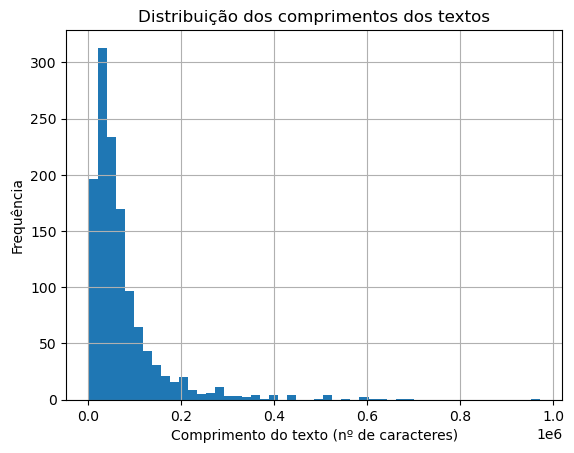

In [37]:
import matplotlib.pyplot as plt

df["Texto"].str.len().hist(bins=50)
plt.xlabel("Comprimento do texto (nº de caracteres)")
plt.ylabel("Frequência")
plt.title("Distribuição dos comprimentos dos textos")
plt.show()